In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('../dataset/shopping_trends_updated.csv')

In [29]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [31]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [40]:
df.columns = [
    'customer_id',
    'age',
    'gender',
    'item_purchased',
    'category',
    'purchase_amount',
    'location',
    'size',
    'color',
    'season',
    'review_rating',
    'subscription_status',
    'shipping_type',
    'discount_applied',
    'promo_code_used',
    'previous_purchases',
    'payment_method',
    'frequency_of_purchases'
]

In [42]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [44]:
labels = ["Young Adult","Adult","Middle-aged","Senior"]

df['age_group'] = pd.qcut(
    df['age'],
    q=4,
    labels=labels
)

In [48]:
df[['age','age_group']].head()

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged


In [49]:
df['frequency_of_purchases'].unique()

<StringArray>
[   'Fortnightly',         'Weekly',       'Annually',      'Quarterly',
      'Bi-Weekly',        'Monthly', 'Every 3 Months']
Length: 7, dtype: str

In [50]:
frequency_mapping = {
    'Weekly':7,
    'Bi-weekly':14,
    'monthly':30,
    'quarterly':90,
    'Annually':365
}

In [51]:
df['frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)

In [55]:
df[['frequency_of_purchases','frequency_days']].head()

,frequency_of_purchases,frequency_days
0,Fortnightly,NaN
1,Fortnightly,NaN
2,Weekly,7.0
3,Weekly,7.0
4,Annually,365.0


In [67]:
df['purchase_amount'].describe()

count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: purchase_amount, dtype: float64

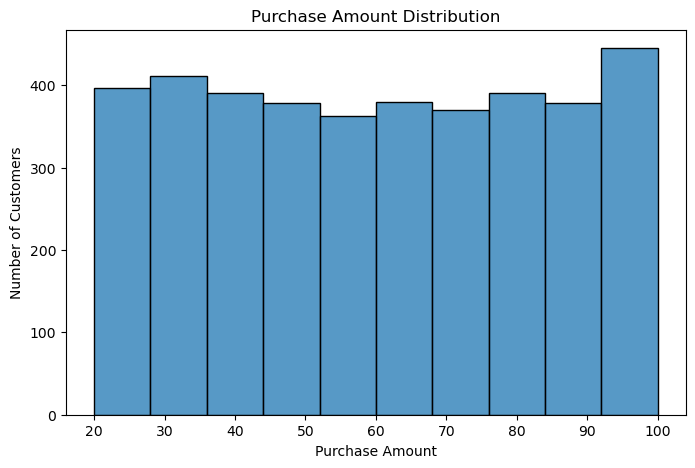

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(df['purchase_amount'],bins=10)

plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount')
plt.ylabel('Number of Customers')

plt.show()

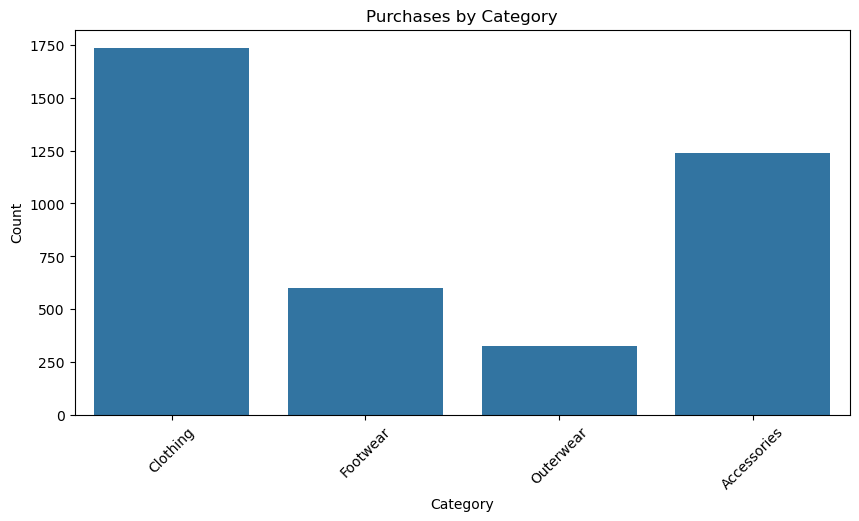

In [75]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='category',
    data=df
)

plt.title('Purchases by Category')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [77]:
gender_spending = df.groupby('gender')['purchase_amount'].mean()
print(gender_spending)

gender
Female    60.249199
Male      59.536199
Name: purchase_amount, dtype: float64


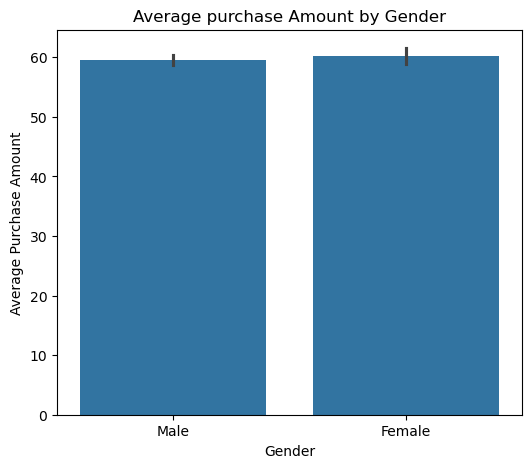

In [78]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='gender',
    y='purchase_amount',
    data=df
)

plt.title('Average purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount')

plt.show()

In [79]:
season_sales=df.groupby('season')['purchase_amount'].sum()

print(season_sales)

season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: purchase_amount, dtype: int64


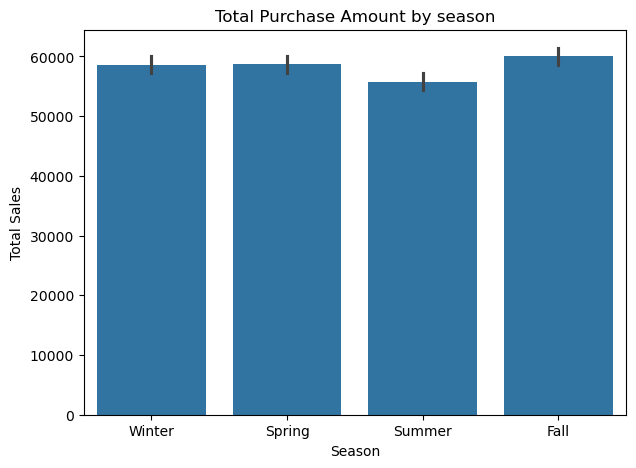

In [80]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='season',
    y='purchase_amount',
    data=df,
    estimator=sum
)

plt.title('Total Purchase Amount by season')
plt.xlabel('Season')
plt.ylabel('Total Sales')

plt.show()

In [81]:
subscription_spending = df.groupby('subscription_status')['purchase_amount'].mean()

print(subscription_spending)

subscription_status
No     59.865121
Yes    59.491928
Name: purchase_amount, dtype: float64


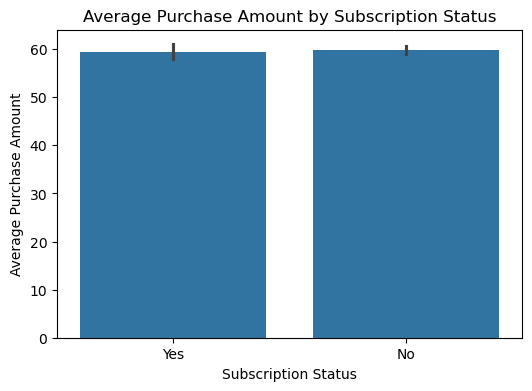

In [85]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='subscription_status',
    y='purchase_amount',
    data=df
)

plt.title('Average Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount')

plt.show()

In [86]:
discount_sales = df.groupby('discount_applied')['purchase_amount'].mean()

print(discount_sales)

discount_applied
No     60.130454
Yes    59.279070
Name: purchase_amount, dtype: float64


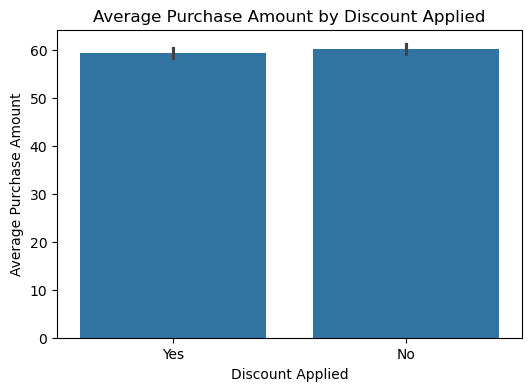

In [87]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='discount_applied',
    y='purchase_amount',
    data=df
)

plt.title('Average Purchase Amount by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Average Purchase Amount')

plt.show()

In [89]:
payment_usage = df['payment_method'].value_counts()

print(payment_usage)

payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


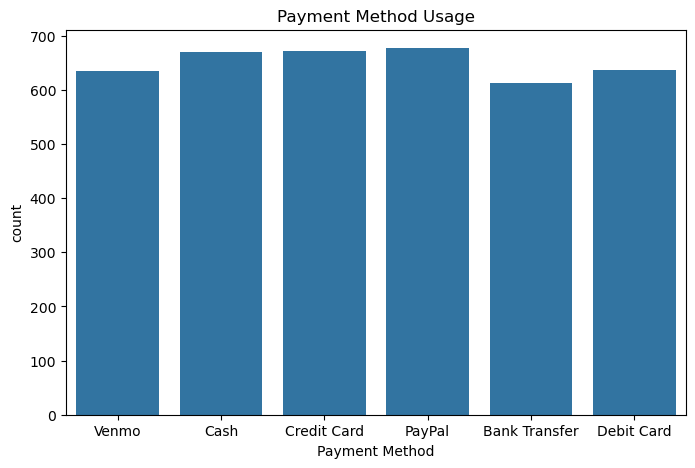

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='payment_method',
    data=df
)

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('count')

plt.show()

In [92]:
payment_usage = df['payment_method'].value_counts()

print(payment_usage)

payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


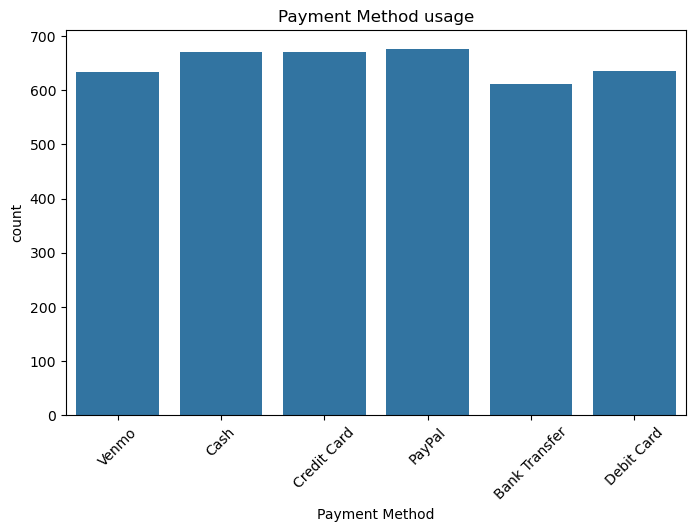

In [95]:
plt.figure(figsize = (8,5))

sns.countplot(
    x='payment_method',
    data=df
)
plt.title('Payment Method usage')
plt.xlabel('Payment Method')
plt.xticks(rotation = 45)

plt.show()

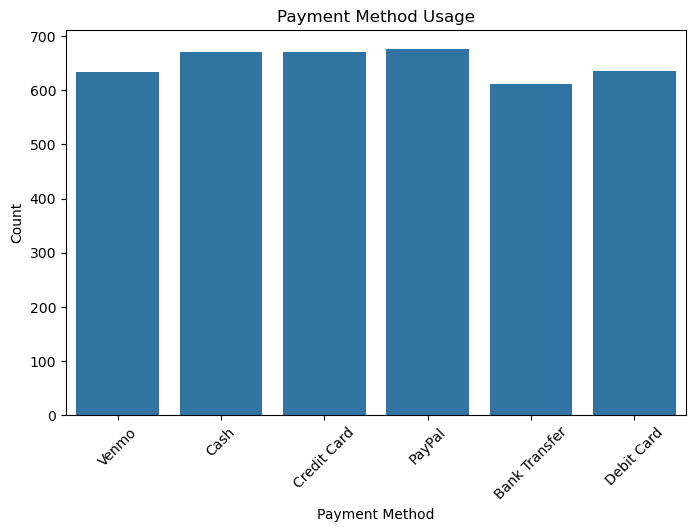

In [98]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='payment_method',
    data=df
)

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()


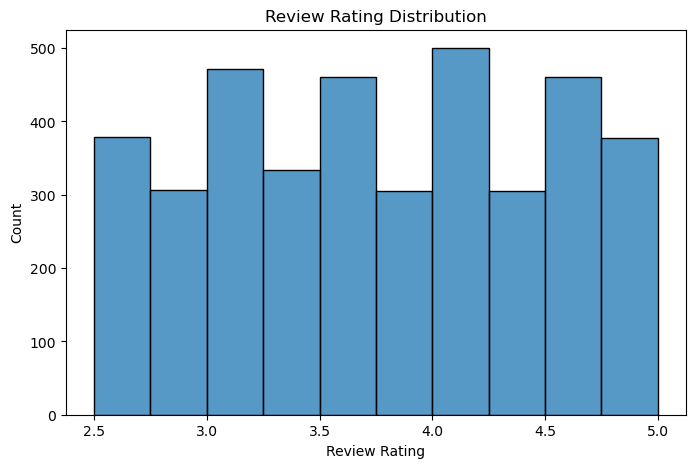

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['review_rating'],
    bins=10
)

plt.title('Review Rating Distribution')
plt.xlabel('Review Rating')
plt.ylabel('Count')

plt.show()

In [101]:
location_Sales = df.groupby('location')['purchase_amount'].sum().sort_values(ascending = False)

print(location_Sales.head())

location
Montana       5784
Illinois      5617
California    5605
Idaho         5587
Nevada        5514
Name: purchase_amount, dtype: int64


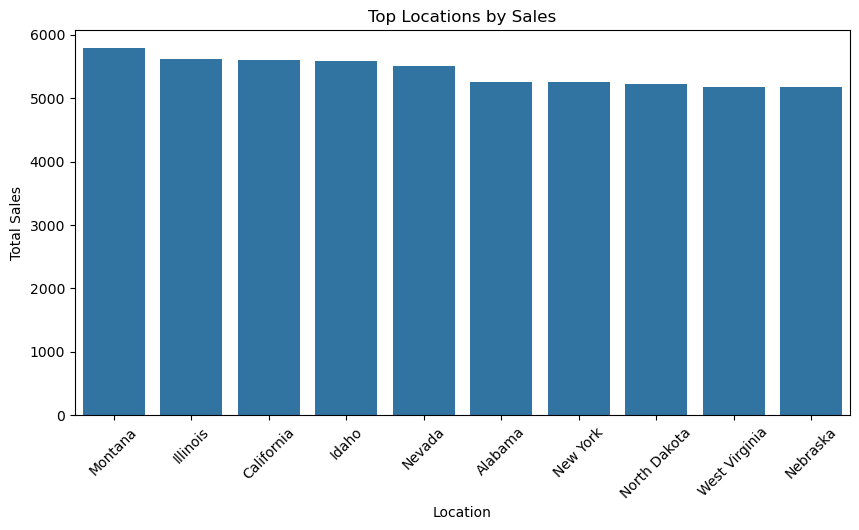

In [102]:
top_locations = location_Sales.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)

plt.title('Top Locations by Sales')
plt.xlabel('Location')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

In [103]:
df.to_csv('../dataset/cleaned_customer_shopping_data.csv',index=False)

In [104]:
payment_usage = df['payment_method'].value_counts()

print(payment_usage)

payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


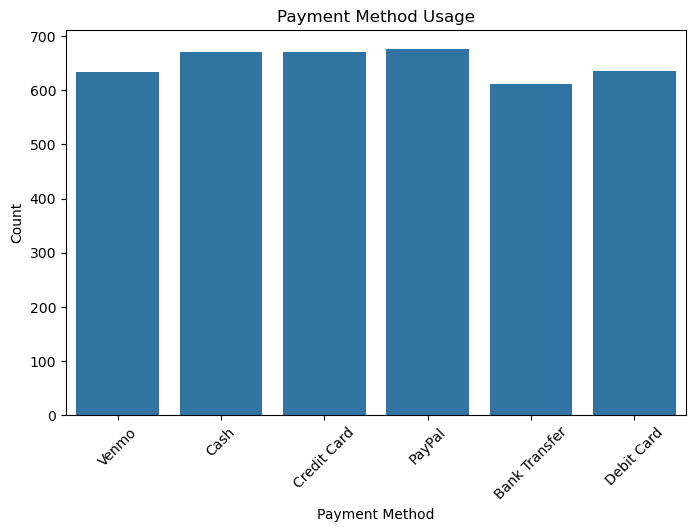

In [105]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='payment_method',
    data=df
)

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

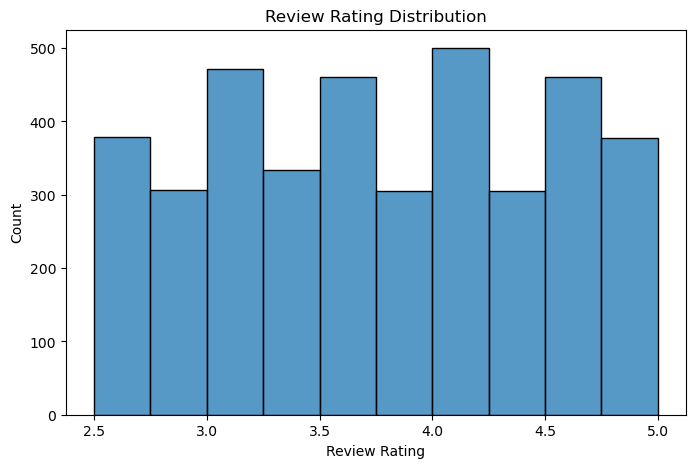

In [106]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['review_rating'],
    bins=10
)

plt.title('Review Rating Distribution')
plt.xlabel('Review Rating')
plt.ylabel('Count')

plt.show()

In [107]:
location_sales = df.groupby('location')['purchase_amount'].sum().sort_values(ascending=False)

print(location_sales.head(10))

location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: purchase_amount, dtype: int64


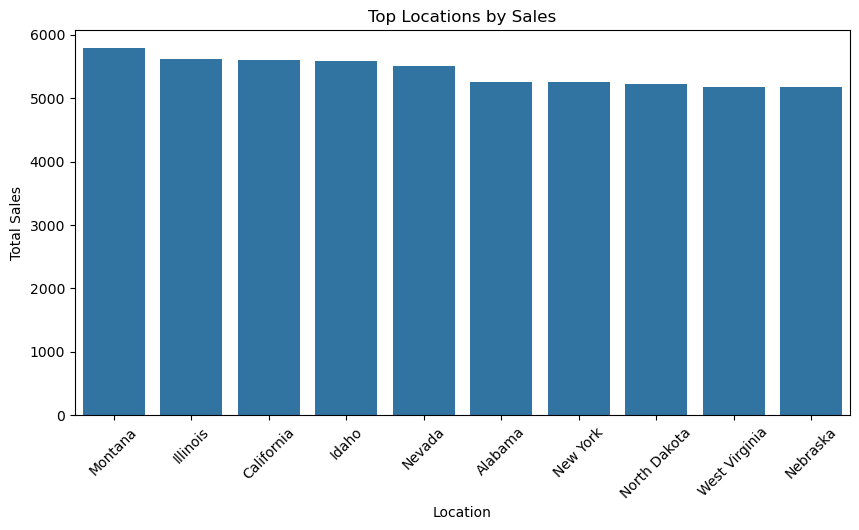

In [108]:
top_locations = location_sales.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)

plt.title('Top Locations by Sales')
plt.xlabel('Location')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

In [109]:
df.to_csv('../dataset/cleaned_customer_shopping_data.csv', index=False)

## Dataset Analysis and Cleanup
The notebook previously failed because `matplotlib` and `seaborn` were not installed in the kernel. The dataset is loaded from `../dataset/shopping_trends_updated.csv` relative to this notebook.

In [35]:
# Basic dataset summary
print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())
print('\nDescriptive statistics for numeric columns:')
print(df.describe(include='number').transpose())

Dataset shape: (3900, 18)

Columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

Data types:
Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object

Missing values:
Customer ID        

In [36]:
# Compact dataset diagnostics
print('shape:', df.shape)
print('columns:', df.columns.tolist())
print('missing values:')
print(df.isna().sum())
print('numeric summary:')
print(df.describe(include='number').loc[['mean','min','max']])

shape: (3900, 18)
columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']
missing values:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64
numeric summary:
      Customer ID        Age  Purchase Amount (USD)  Review Rating  \
mean       1950.5  44.068462              59.764359       3.7499

### Additional Data Quality Checks
This cell checks for duplicate rows and summarizes core categorical fields.

In [37]:
# Data quality checks
print('duplicate rows:', df.duplicated().sum())
print('\nTop categories:')
print(df['Category'].value_counts().head(10))
print('\nTop payment methods:')
print(df['Payment Method'].value_counts())
print('\nTop 5 purchased items:')
print(df['Item Purchased'].value_counts().head(5))

duplicate rows: 0

Top categories:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Top payment methods:
Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

Top 5 purchased items:
Item Purchased
Blouse     171
Pants      171
Jewelry    171
Shirt      169
Dress      166
Name: count, dtype: int64
